# Tutorial 6: Galactic Binaries & RJMCMC

In the sixth tutorial, we will examine Galactic Binary waveforms. We will then use them in fixed-dimensional MCMC and then in RJMCMC. We use RJMCMC to perform model selection on the number of sources in the data. 

In [1]:
# # if running in google colab
# !apt-get install liblapacke-dev libgsl-dev
# !pip install eryn lisaanalysistools chainconsumer corner
# !pip install gbgpu

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
from lisatools.utils.constants import *
from lisatools.sensitivity import get_sensitivity

## Task 1: Build and plot a Galacic Binary waveform using `GBGPU`

We will start by generating Galactic Binary waveforms with `GBGPU`. Pick reasonable parameters, build a waveform and plot it against the LISA A channel TDI Sensitivity Curve (`A1TDISens`) in the characteristic strain representation. You can access the information after waveform generation as attributes on the class. This may be updated in the future.

Useful documentation:
* [GBGPU](https://mikekatz04.github.io/GBGPU/html/user/main.html#gbgpu.gbgpu.GBGPU)

银河系双星（Galactic Binary）的引力波信号

In [3]:
# imports
from gbgpu.gbgpu import GBGPU

In [4]:
gb = GBGPU()

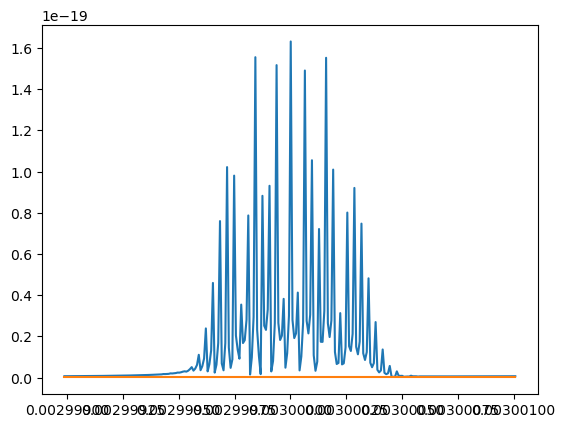

In [5]:
amp = 2e-23  
f0 = 3e-3  
fdot = 7.538331e-18  
fddot = 0.0 
phi0 = 0.1 
iota = 0.2  
psi = 0.3 
lam = 4.15  
beta = -0.12  
Tobs = 4 * YRSID_SI
gb.run_wave(amp, f0, fdot, fddot, phi0, iota, psi, lam, beta, N=256) #N=256是一个经验值
#如果 $N$ 取得太小（比如 16），你会发现画出来的波形在边缘被强行切断了
# 如果取得太大（比如 2048），你的代码运行速度会明显变慢。
plt.plot(gb.freqs[0], gb.freqs[0] * np.abs(gb.A[0]))
#gb.A[0],返回A道的信息
plt.plot(gb.freqs[0], get_sensitivity(gb.freqs[0], sens_fn="A1TDISens", return_type="char_strain"))

In [6]:
print(gb.freqs.shape)
print(gb.freqs[0].shape)
print(gb.A[0].shape)#复数是因为既有相位也有振幅
print(gb.freqs)

(1, 256)
(256,)
(256,)
[[0.00299899 0.002999   0.002999   0.00299901 0.00299902 0.00299903
  0.00299904 0.00299904 0.00299905 0.00299906 0.00299907 0.00299907
  0.00299908 0.00299909 0.0029991  0.00299911 0.00299911 0.00299912
  0.00299913 0.00299914 0.00299915 0.00299915 0.00299916 0.00299917
  0.00299918 0.00299919 0.00299919 0.0029992  0.00299921 0.00299922
  0.00299923 0.00299923 0.00299924 0.00299925 0.00299926 0.00299927
  0.00299927 0.00299928 0.00299929 0.0029993  0.0029993  0.00299931
  0.00299932 0.00299933 0.00299934 0.00299934 0.00299935 0.00299936
  0.00299937 0.00299938 0.00299938 0.00299939 0.0029994  0.00299941
  0.00299942 0.00299942 0.00299943 0.00299944 0.00299945 0.00299946
  0.00299946 0.00299947 0.00299948 0.00299949 0.00299949 0.0029995
  0.00299951 0.00299952 0.00299953 0.00299953 0.00299954 0.00299955
  0.00299956 0.00299957 0.00299957 0.00299958 0.00299959 0.0029996
  0.00299961 0.00299961 0.00299962 0.00299963 0.00299964 0.00299965
  0.00299965 0.00299966 0.0

## Task 2: Run an MCMC over a single GB source

Run a fixed-dimensional MCMC run with a chosen GB source. Fix the sky location for now to simplify the problem computationally (this is especially important for the next section on RJ with GBs). So, you will sample over 6 of the 8 parameters. Discuss or think about reasonable priors for these parameters and how you would determine that. For simplicity, we recommend using tightly (but not too tightly) bound uniform distributions for this example setup.

There is a faster `get_ll` method on the `GBGPU` class. However, it may be easier to use the full `AnalysisContainer` setup. This will make the RJ part more straight forward, but is not actually ideal for fixed-dimensional MCMC on GBs. 

After the run is complete, plot the posterior distribution with `chainconsumer` or `corner`. 

In [7]:
#imports
from eryn.prior import uniform_dist, ProbDistContainer

In [8]:
priors = {"gb": ProbDistContainer({
    0: uniform_dist(1e-23, 1e-21),
    1: uniform_dist(0.00299995, 0.00300005),
    2: uniform_dist(1e-18, 1e-17),
    3: uniform_dist(0.0, 2 * np.pi),
    4: uniform_dist(0.0, np.pi),  # should be over cosine of inclination, but this is simpler for examples
    5: uniform_dist(0.0, np.pi)
})}
# lambda，beta均已知，且这里给出了银心的位置
lam = 4.13
beta = -0.15
default_values = np.array([lam, beta])

In [9]:
from lisatools.analysiscontainer import AnalysisContainer
from lisatools.datacontainer import DataResidualArray
from lisatools.sensitivity import AE1SensitivityMatrix

In [10]:
N_wave = 256
def like_wrap(x, analysis1, data, fd, Tobs, dt, default_values):
    input_parameters = np.zeros(9)
    #其中第3个位置fddot保持为0即可。
    input_parameters[np.array([0, 1, 2, 4, 5, 6])] = x
    input_parameters[np.array([7, 8])] = default_values
    gb.run_wave(*input_parameters, T=Tobs, dt=dt, N=N_wave) 
    
    A = gb.A[0]
    E = gb.E[0]
    # 真实的信号和生成的256个点的信号对齐
    start_ind = int(gb.freqs[0][0] / df)
    template = DataResidualArray(np.array([A, E]), f_arr=gb.freqs[0])
    data_tmp = DataResidualArray(data[:, start_ind:start_ind + N_wave], f_arr=fd[start_ind:start_ind + N_wave])
    sens_mat = AE1SensitivityMatrix(data_tmp.f_arr)
    analysis = AnalysisContainer(data_tmp, sens_mat)
    ll = analysis.template_likelihood(template)
    return ll

$df=\frac{1}{T_{obs}}$,总的时间为$T_{obs}$，则总的时间能看到的最慢的，Hz最小的就是以观测时间为周期的波形，这也就是最小分辨率

关于最大的频率，是通过采样频率（每隔多长时间采样一次）给出的，此处的dt=5s，那么也就是最快5s采样一次，则只有当这个采样时间我们可以记录到波峰波谷则就认为可以记录一个波形（T/2），所以最大的频率也就是$\frac{1}{2 dt}$

In [11]:
injection_params = np.array([
    amp, 
    f0,
    fdot,
    0.0,
    phi0,
    iota,
    psi,
    lam,
    beta
])
print(injection_params)

Tobs = YRSID_SI
dt = 5.0
N = int(Tobs / dt)
Tobs = N * dt
# 需要更新一个Tobs严格遵循 $N$ 乘以 $dt$，让Tobs稍微缩水。
df = 1 / Tobs
#np.asarray 的作用是转化为数组。
f_arr = np.arange(0.0, 1/(2 * dt) + df, df)
data_orig = np.asarray(gb.inject_signal(*injection_params, T=Tobs, dt=dt, N=N_wave))
# data.orig.copy()是为了保证原始数据的纯正，即使下面的修改也不会影响data_orig
data = DataResidualArray(data_orig.copy(), f_arr=f_arr)
# data用DataResidualArray将两个绑定一起，所以data_orig的[0]一定是f=0Hz
sens_mat = AE1SensitivityMatrix(f_arr)
analysis = AnalysisContainer(data, sens_mat)

[ 2.000000e-23  3.000000e-03  7.538331e-18  0.000000e+00  1.000000e-01
  2.000000e-01  3.000000e-01  4.130000e+00 -1.500000e-01]


/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:655: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:657: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:659: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:664: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:666: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi * frq / C_SI) ** 2


In [12]:
np.trapz=np.trapezoid

In [13]:
sampling_injection_params = np.array([
    amp,
    f0,
    fdot,
    phi0,
    iota,
    psi
])
print(f0)
like_wrap(sampling_injection_params, analysis, data_orig, analysis.data_res_arr.f_arr, Tobs, dt, default_values)

0.003


np.float64(-0.0)

这里不等于0，是因为f_0也就是第一个开始的频率，f_0/df不等于0，没有完整的落在格子上

In [14]:
print(analysis.data_res_arr.f_arr)
print(f_arr)
print(f_arr==analysis.data_res_arr.f_arr)

[0.00000000e+00 3.16875406e-08 6.33750811e-08 ... 9.99999525e-02
 9.99999842e-02 1.00000016e-01]
[0.00000000e+00 3.16875406e-08 6.33750811e-08 ... 9.99999525e-02
 9.99999842e-02 1.00000016e-01]
[ True  True  True ...  True  True  True]


In [15]:
from eryn.ensemble import EnsembleSampler
from eryn.state import State

我们应该设置边界，
对于
```
  3: uniform_dist(0.0, 2 * np.pi),
    4: uniform_dist(0.0, np.pi),  # should be over cosine of inclination, but this is simpler for examples
    5: uniform_dist(0.0, np.pi)
```
这几个参数需要设置边界，
periodic = {"gb": {3: 2 * np.pi
4：np.pi
5:np.pi
}}
并在EnsembleSampler中增加参数periodic。

In [16]:
# 定义周期性边界
periodic = {
    "gb": {
        3: 2 * np.pi,  # phi0 周期是 2π
        4: np.pi,      # iota (倾角) 简单设置周期为 π
        5: np.pi       # psi (极化角) 周期是 π
    }
}

In [17]:
ndims = {"gb": 6}
nwalkers = 24
ntemps = 10
sampler = EnsembleSampler(
    nwalkers,
    ndims, 
    like_wrap,
    priors,
    branch_names=["gb"],
    args=(analysis, data_orig, analysis.data_res_arr.f_arr, Tobs, dt, default_values),
    tempering_kwargs=dict(ntemps=10),
    nleaves_max={"gb": 1},
    periodic=periodic,
)

In [18]:
start_state = State({"gb": priors["gb"].rvs(size=(ntemps, nwalkers, 1))})

In [19]:
np.in1d = np.isin

In [20]:
nsteps = 3000
sampler.run_mcmc(start_state, nsteps, burn=1000, progress=True)

100%|██████████| 3000/3000 [08:42<00:00,  5.74it/s]


In [21]:
from chainconsumer import Chain, ChainConsumer
import pandas as pd

Parameter fdot in chain 1 is not constrained
Parameter phi0 in chain 1 is not constrained
Parameter iota in chain 1 is not constrained
Parameter psi in chain 1 is not constrained


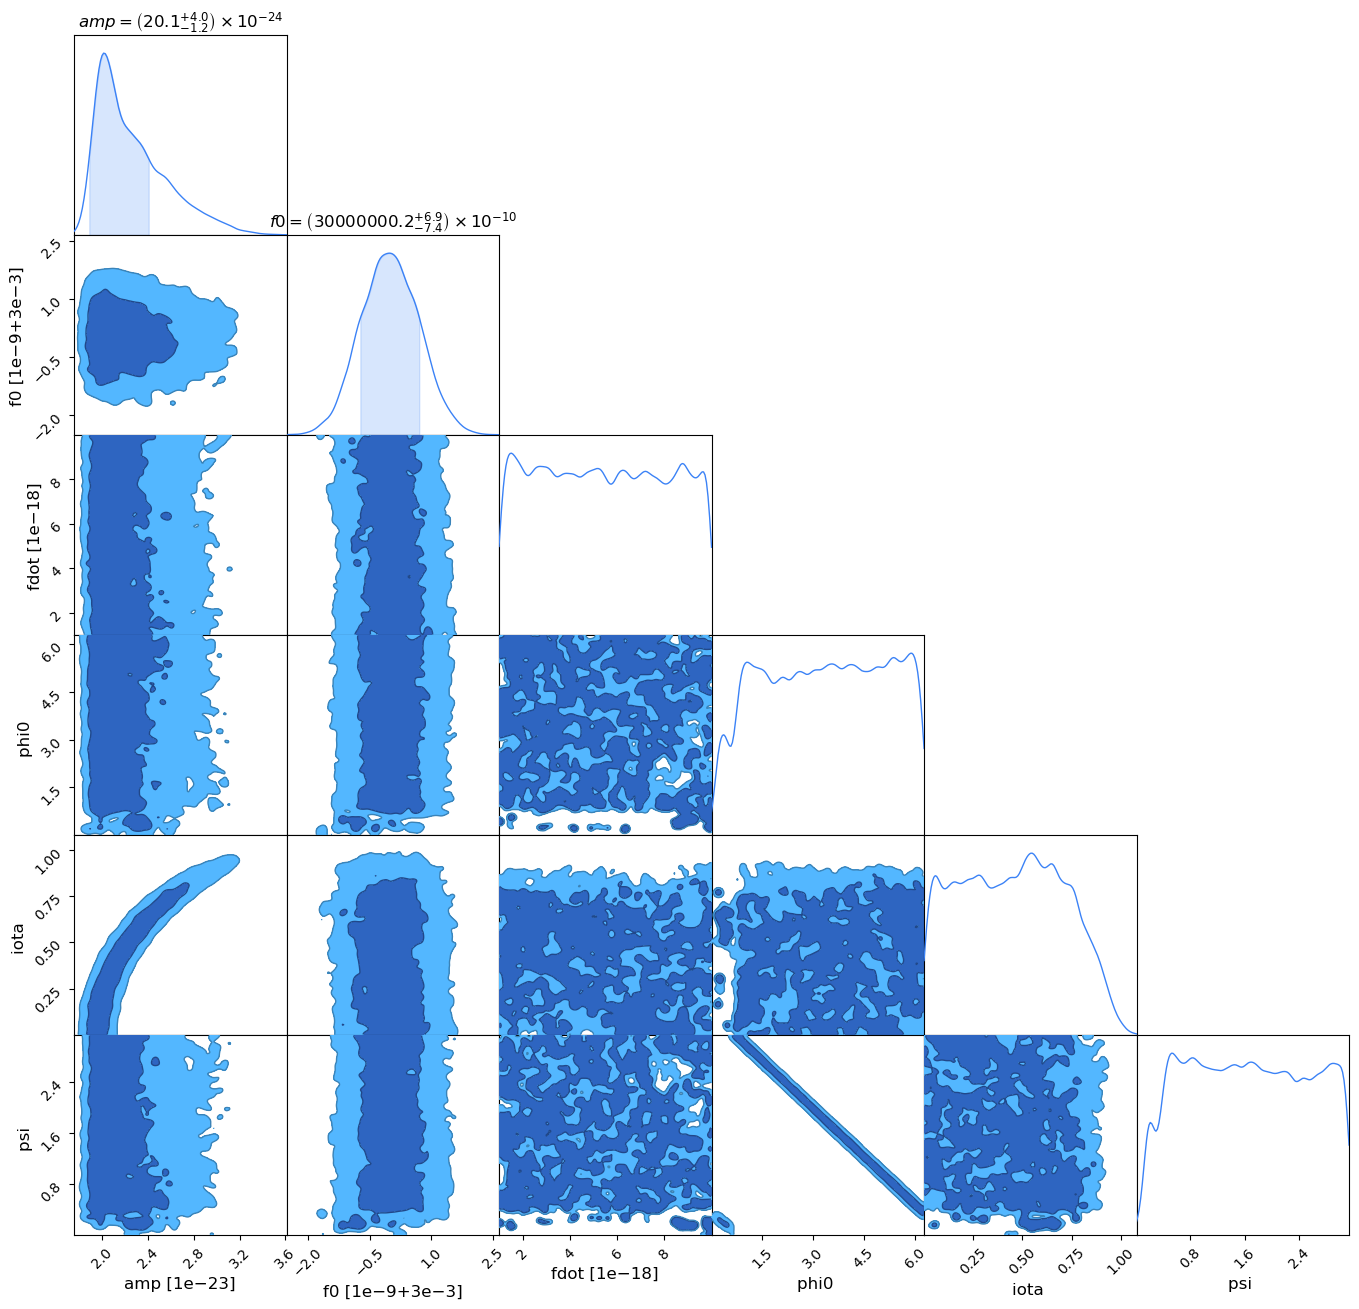

In [22]:
cold_chain = sampler.get_chain()["gb"][:, 0, :, 0].reshape(-1, 6)
# 将所有的数据（-1），分成6行，变成（20000，6）
c = ChainConsumer()

df1 = pd.DataFrame({name: val for name, val in zip(["amp", "f0", "fdot", "phi0", "iota", "psi"], cold_chain.T)}) 
c.add_chain(Chain(samples=df1, name=str(1)))
fig = c.plotter.plot()

为了保持总信号不变，A 变大时 B 也必须跟着变大（或变小）的补偿机制，在二维图上画出来，就是一个倾斜的椭圆！

所以如果是椭圆形，长条形，说明这两个参数互相有关。

如果是圆形则这两个参数无关。

## Task 3: RJ with GBs

Our final task will be to run RJMCMC on a few close Galactic Binaries. The key component here is the "global" Likelihood function. Work to build a function that takes from Eryn and adjustable length array of templates to be summed into a global template prior to the Likelihood computations. This will be a bit tedious, but is very important for understanding this process. 

There is another nuance in this problem that must be dealt with to get this all to work. In the fixed-dimensional case with one binary, the default stretch proposal is effectively invariant to the scale along each dimension as there is no mixing of dimensional information when making a  proposal, $\vec{Y} = \vec{X}_j + z\left(\vec{X}_i - \vec{X}_j\right)$. The default `GaussianMove` that we used in tutorial 5 requires an inversion of the covariance matrix. If we sample in the parameters we used above ($A$, $f_0$, $\dot{f}$, etc.), the scale differences between parameters will cause numerical issues with matrix inversion and multiplication. 

There is a small variety of ways to deal with this. Here are two possibilities:

1) You can log scale and reduce each parmeter so they are all of order 1. This would involve changing the priors and making sure you include this conversion in your Likelihood function. You can use `eryn.utils.TransformContainer` to do this conversion if you would like.
2) You can create your own proposal where you assume a diagonal covariance and generate the information yourself. I have chosen to take this route for this example. **Hint**: the Eryn tutorial has an example of this. 

If you really want to get fancy: 

In the setup described, every source that currently has `inds=True` will be moved together. That means, if a given walker has 5 sources, all 5 sources' parameters will change at the same time. This can hurt the acceptance fraction of these moves. In reality, you may want to use Gibbs sampling to sample one or a few sources at once. You can accomplish this using the `gibbs_sampling_setup` kwarg for `eryn.moves.Move`. 

Useful documentation:

* [MHMove](https://mikekatz04.github.io/Eryn/html/user/moves.html#eryn.moves.MHMove)
* [TransformContainer](https://mikekatz04.github.io/Eryn/html/user/utils.html#eryn.utils.TransformContainer)
* [Move](https://mikekatz04.github.io/Eryn/html/user/moves.html#eryn.moves.Move)

If you can run the sampler and confirm the Likelihoods are working, then consider this completed. The time alloted for the tutorial and the overall setup needed to run this RJ setup correclty require a lot more runtime for reasonable results. So, you can plot what comes out, but it will become more accurate as your run the sampler longer. 

In [23]:
# imports
from eryn.moves import MHMove

自下而上封装，自上而下调用

template 是一个形状为 (2, 全频段点数) 的二维数组。

template[0, :] 是 A 通道的全频段波形。

template[1, :] 是 E 通道的全频段波形。

In [24]:
def fill_template(template, A, E, freqs, Tobs, dt):
    for i in range(A.shape[0]):
        # 循环每一个信号，有几行？
        start_ind = gb.start_inds[i]#自动求算开始时间的index
        #index是这样的，int(f/df)就是这个f的index
        end_ind = start_ind + N_wave
        assert end_ind - start_ind == gb.freqs.shape[1]#检验取得坐标是否正确
        template[0, start_ind:end_ind] += A[i]
        #等价于template[0, start:end] = template[0, start:end] + A[i]
        # 波的叠加
        template[1, start_ind:end_ind] += E[i]
# template中的0->A,1->E道信号
def generate_global_template(template, params_all, Tobs, dt):
    gb.run_wave(*params_all.T, T=Tobs, dt=dt, N=N_wave) 
    #这里return了生成的波形，.T变成（9，N）的矩阵，*变成9个独立的一维数组
    fill_template(template, gb.A, gb.E, gb.freqs, Tobs, dt)
    
def global_log_likelihood(params_all, analysis, Tobs, dt, default_values):
    input_parameters = np.zeros((params_all.shape[0], 9))
    # 这里初始化一个（N，9）shape的0矩阵，N个信号，shape[0],取得是行数（N，6），也就是取N
    input_parameters[:, np.array([0, 1, 2, 4, 5, 6])] = params_all
    input_parameters[:, np.array([7, 8])] = default_values
    template = np.zeros_like(analysis.data_res_arr[:])
    #初始化，都是0
    """Data information."""
    #这里return其实就是DataResidualArray得信息
    generate_global_template(template, input_parameters, Tobs, dt)
    template_in = DataResidualArray(template, f_arr=f_arr)
    #这个是个对齐操作，template和f_arr对齐，f_arr从0开始
    ll = analysis.template_likelihood(template_in)
    # 增加一个维度
    return ll

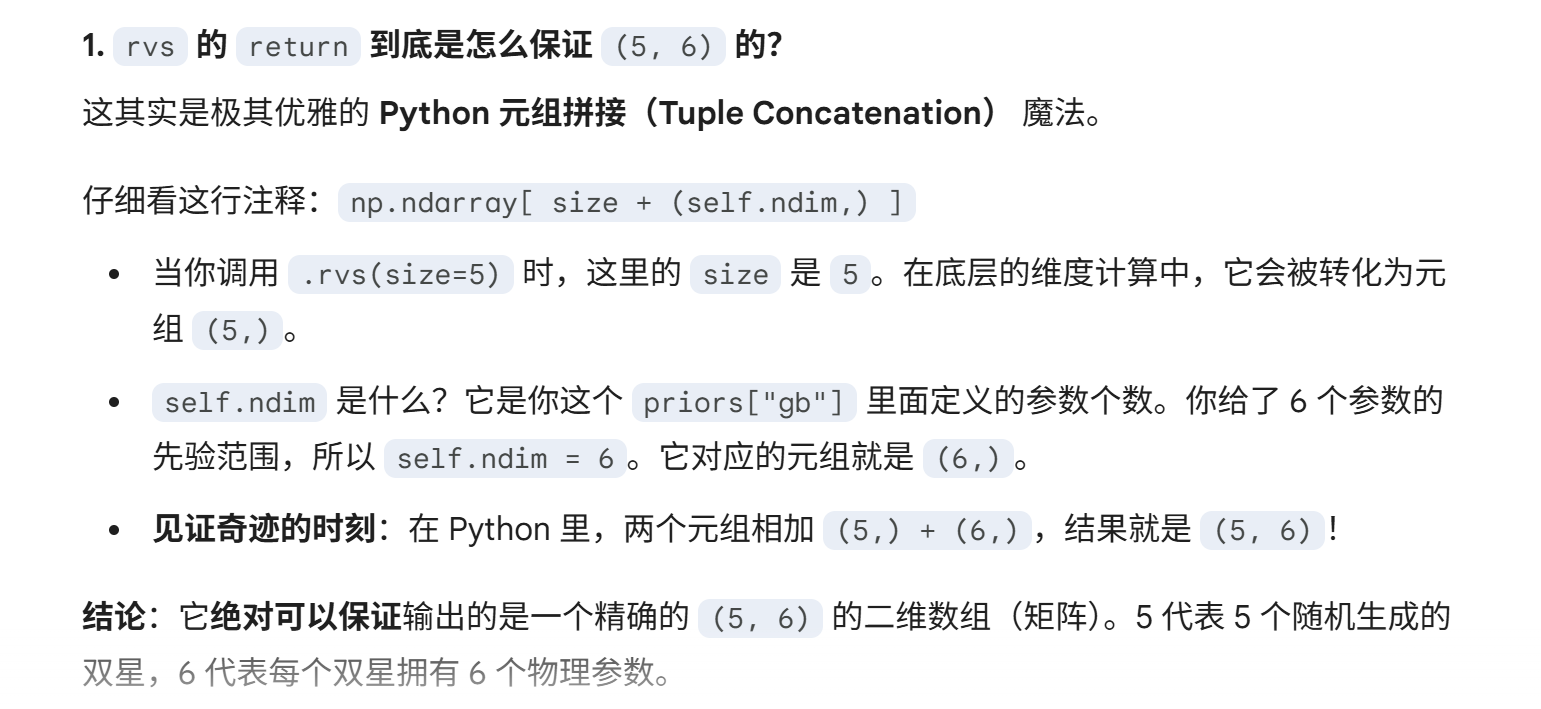
``injection_params_all = priors["gb"].rvs(size=5)``,size的变化

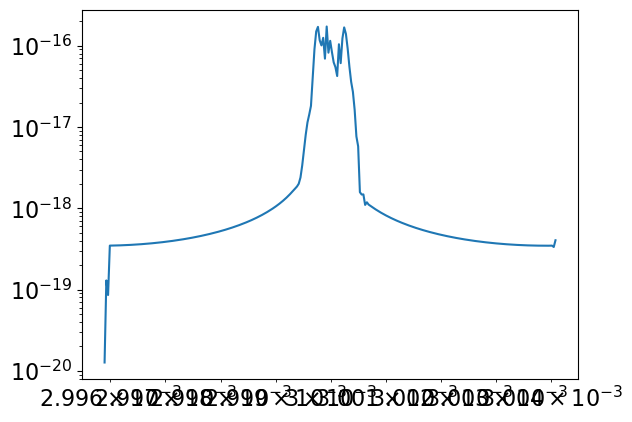

In [25]:
injection_params_all = priors["gb"].rvs(size=5)
#从先验中抽出5个数据，5个源
input_parameters = np.zeros((injection_params_all.shape[0], 9))
input_parameters[:, np.array([0, 1, 2, 4, 5, 6])] = injection_params_all
input_parameters[:, np.array([7, 8])] = default_values
data = np.zeros((2, len(f_arr)), dtype=complex)
#data初始化，2是A和E道
generate_global_template(data, input_parameters, Tobs, dt)
#generate_global_template是特别版本的get_wave,就是要将5个叠加一下就行了
inds = np.where(data[0])
# inds = np.where(data[0]) 的作用是：“找出 A 通道（data[0]）里，不是0的那些位置的下标”。
plt.loglog(f_arr[inds], np.abs(data[0][inds]))

In [26]:
data_arr = DataResidualArray(data, f_arr=f_arr)
sens_mat = AE1SensitivityMatrix(f_arr)
analysis = AnalysisContainer(data_arr, sens_mat)

/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:655: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:657: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:659: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:664: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:666: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi * frq / C_SI) ** 2


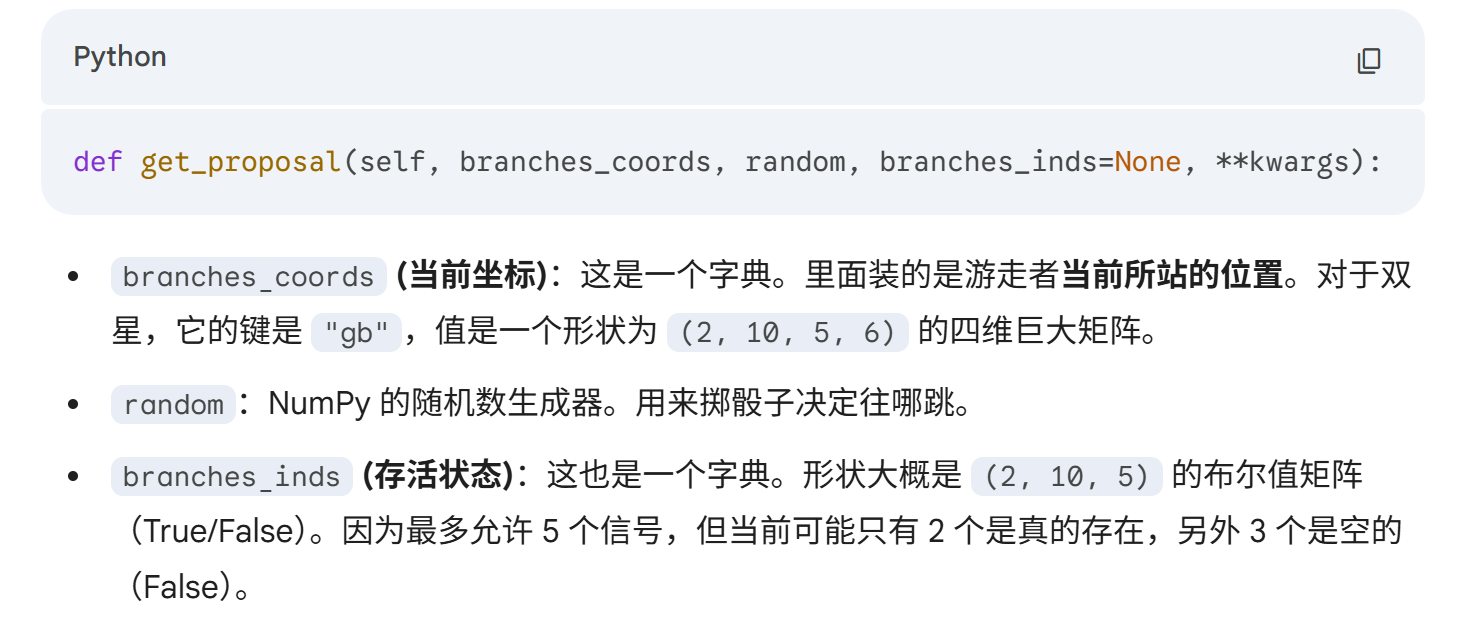

In [27]:
class NonScaledDiagonalGaussianMove(MHMove):
    def __init__(self, cov_all, *args, **kwargs):

        for branch_name, cov in cov_all.items():
            assert isinstance(cov, np.ndarray) and cov.ndim == 1
            # 传入的是一维数组，而不是协方差矩阵，也就是说两个数据没有关联
        self.cov = cov_all
        super(NonScaledDiagonalGaussianMove, self).__init__(*args, **kwargs)
        #呼叫父类 MHMove 完成标准初始化
    def get_proposal(self, branches_coords, random, branches_inds=None, **kwargs):
        # 提案就是告诉walkers如何走的方案
        assert branches_inds is not None #必须有walker被启用
        new_points = {}
        for name, cov in self.cov.items():
            assert name in branches_coords
            coords = branches_coords[name]# 取出这一类
            inds = branches_inds[name]# 取出这一类
            
            ntemps, nwalkers, nleaves_max, ndim = coords.shape
            #将coords拆开
            # generate sigma from normal distribution
            sigma = random.randn(ntemps, nwalkers)#对于每个温度和每一个walker生成一个随机的数

            tmp = np.zeros_like(coords)
            #初始化，也就是4D的一个0矩阵
            tmp = coords + sigma[:, :, None, None] * cov[None, None, None, :]
            #新坐标tmp

            # symmetric
            new_points[name] = np.zeros_like(coords)

            # this is not necessary as the inds will remove there changes in the parent class
            # but I put it here to indicate to think about it
            new_points[name][inds] = tmp[inds]
            #一个 NumPy 多维数组（Array）！ 在数组的方括号里放一个布尔矩阵，“布尔掩码索引（Boolean Masking）”。
            #用来判断“生死”
        # symmetric
        factors = np.zeros((ntemps, nwalkers))
        #从a->b,b->a的跳动是等价的，则factors=0.->ln(1)=0
        return new_points, factors

它们相乘 sigma[...] * cov[...],其实分析出来的（2，10，1，6）是维度变化的结果，对于计算的结果是简单的，就是对应的ntemps，nwalkers，nleaves，和参数相乘，实质上都是参数相乘，只是需要维数相同，但是做物理的其实只要明白维数相同即可，对应参数相乘

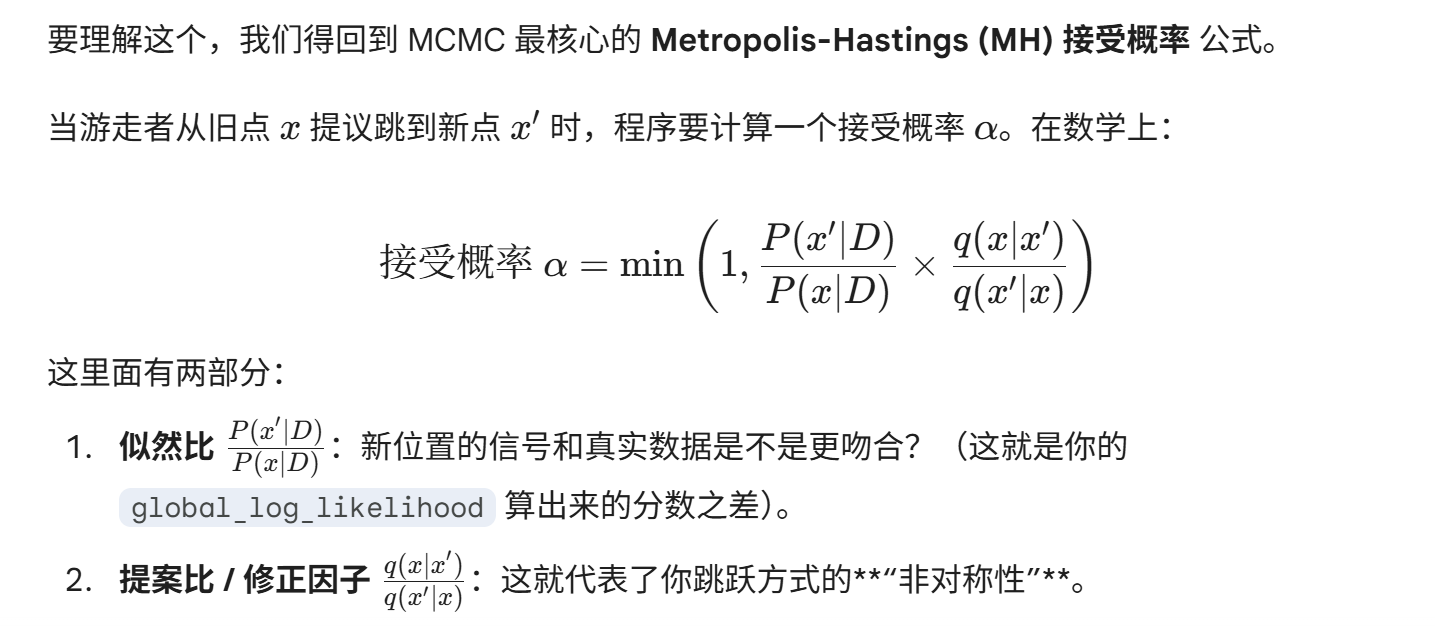
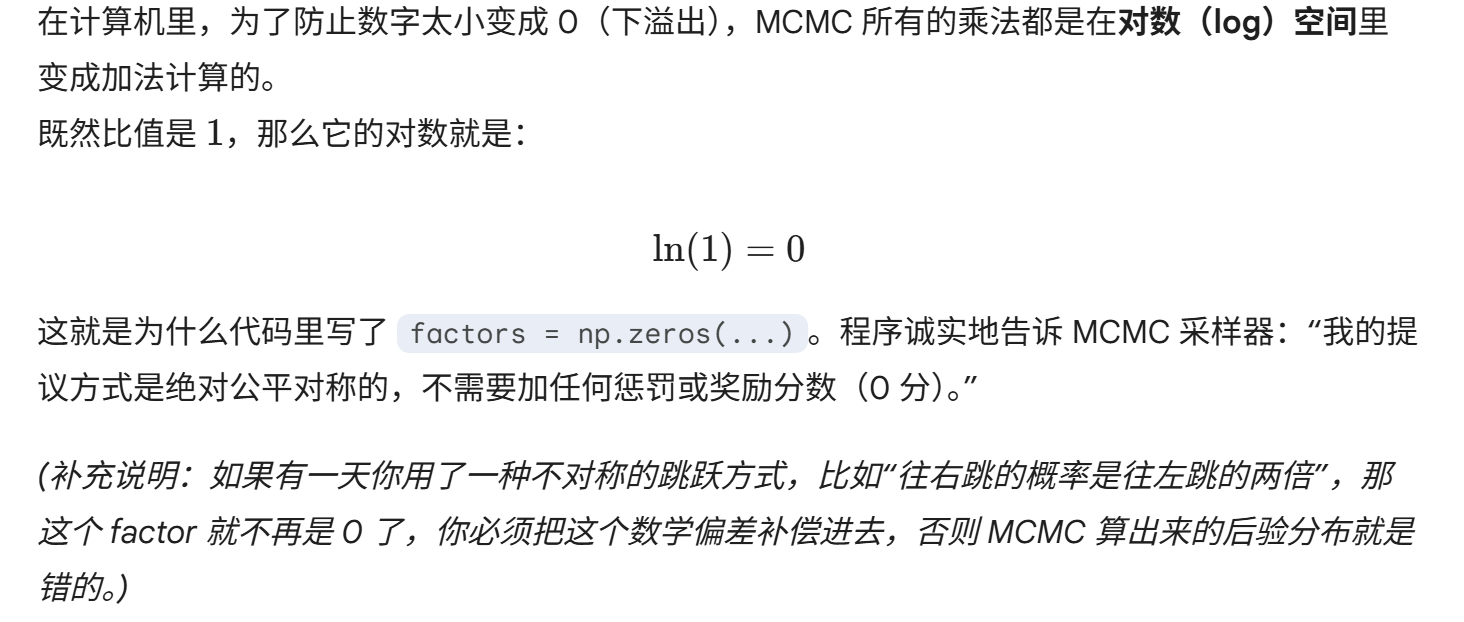

In [28]:
nleaves_max = {"gb": 10}
nleaves_min = {"gb": 0}
ndims = {"gb": 6}
nwalkers = 14
ntemps = 12
lam = 4.13
beta = -0.15
# [lam, beta] of galactic center
default_values = np.array([lam, beta])
cov    = {"gb": np.array([1e-24, 1e-10, 1e-19, 0.01, 0.01, 0.01])}
moves = NonScaledDiagonalGaussianMove(cov)
sampler_rj = EnsembleSampler(
    nwalkers,
    ndims,
    global_log_likelihood,
    priors,
    branch_names=["gb"],
    nleaves_max=nleaves_max,
    nleaves_min=nleaves_min,
    args=(analysis, Tobs, dt, default_values),
    rj_moves=True,
    moves=moves,
    tempering_kwargs=dict(ntemps=ntemps)
)
#标准步骤

In [29]:
start_points = {"gb": priors["gb"].rvs(size=(ntemps, nwalkers, nleaves_max["gb"]))}
inds_tmp = np.zeros((ntemps, nwalkers, nleaves_max["gb"]), dtype=bool)
inds_tmp[:, :, 1] = True#假设有一个源
start_state = State(start_points, inds={"gb": inds_tmp})
nsteps = 10
end_state = sampler_rj.run_mcmc(start_state, nsteps, progress=True)

100%|██████████| 10/10 [14:10<00:00, 85.01s/it]


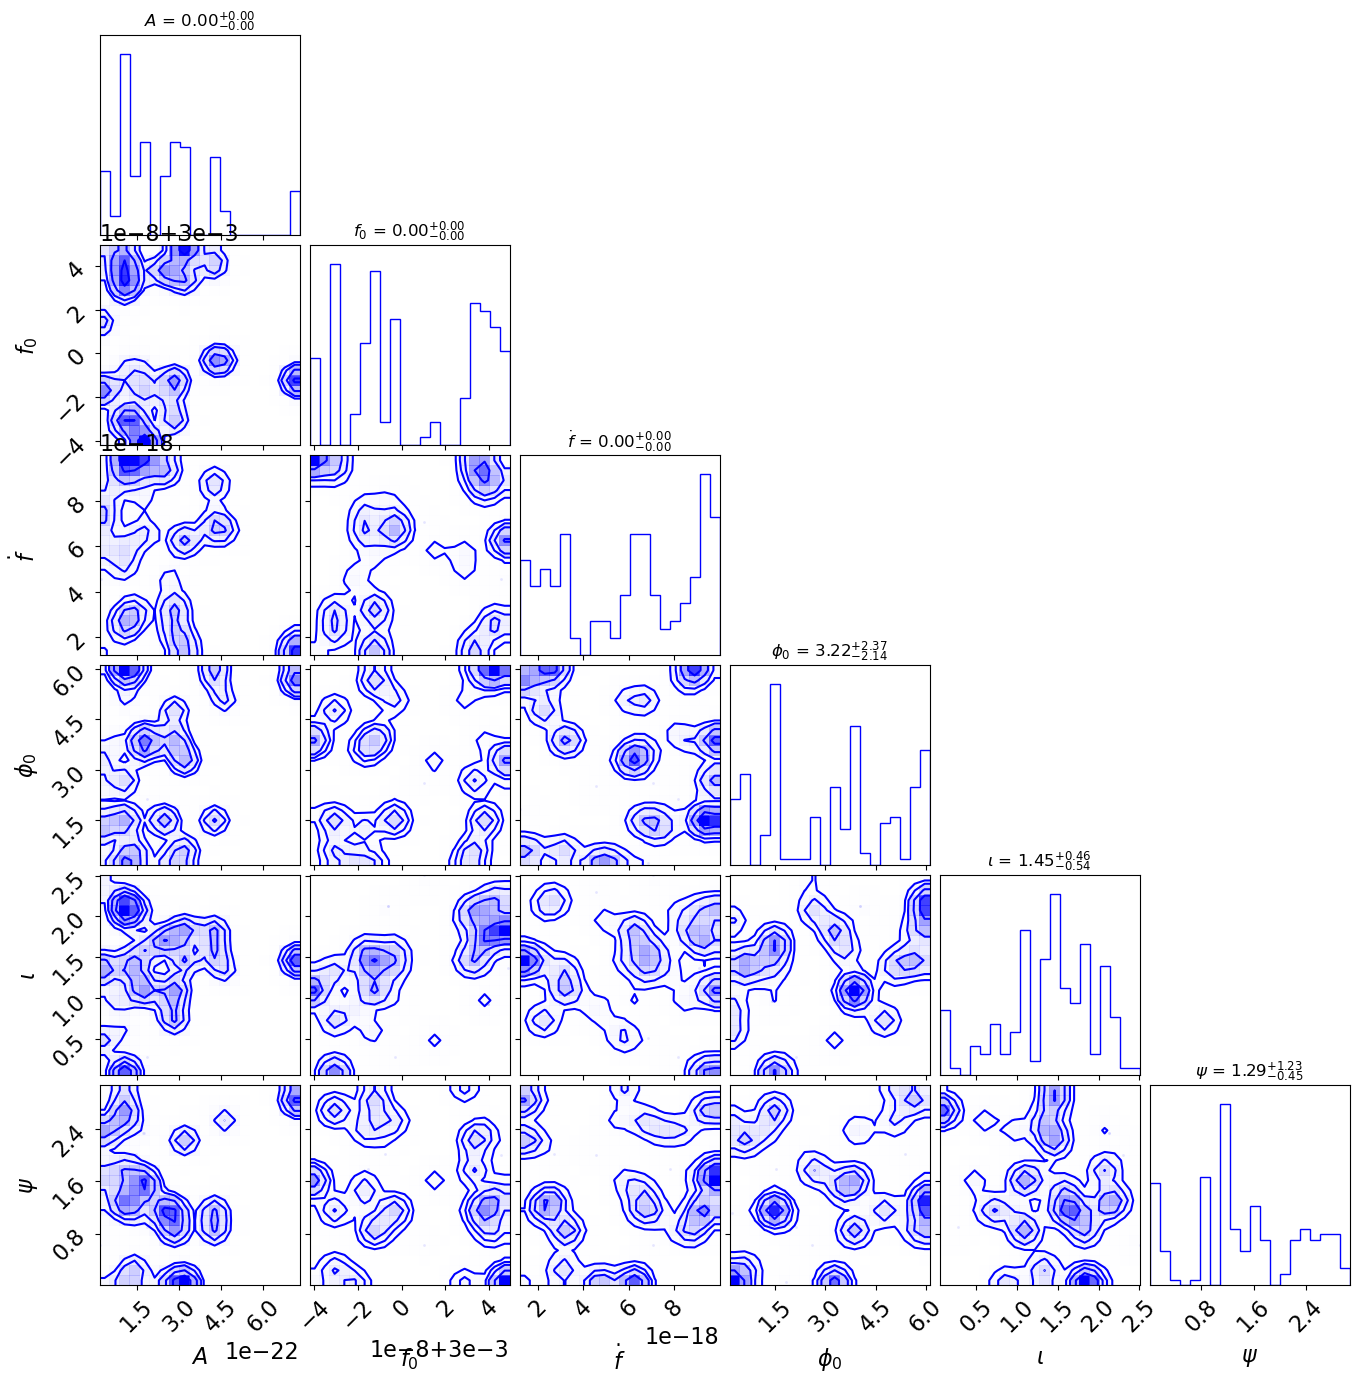

In [31]:
import corner
import matplotlib.pyplot as plt

# 1. 提取采样链和“生死名单”（记得加上分支名字 "gb"）
chain = sampler_rj.get_chain()["gb"]
inds = sampler_rj.get_inds()["gb"]

# 2. 锁定冷链 (Temperature = 0)
# 因为你只跑了 10 步，我们就不切预热期了（burn设为0）。
# 等你以后跑 10000 步时，可以把这里改成 burn = 2000
burn = 0
cold_chain = chain[burn:, 0, :, :, :]  # 形状: (nsteps, nwalkers, nleaves_max, 6)
cold_inds = inds[burn:, 0, :, :]       # 形状: (nsteps, nwalkers, nleaves_max)

# 3. 过滤并压平！
# 把布尔矩阵 cold_inds 直接当做索引，塞进 cold_chain 里。
# 它会瞬间把所有标记为 True 的活信号抽出来，拼成一个极其干净的二维矩阵。
active_samples = cold_chain[cold_inds] 
# 现在的 active_samples 形状变成了 (有效信号总数, 6)

# 4. 定义参数名字并画图
labels = [r"$A$", r"$f_0$", r"$\dot{f}$", r"$\phi_0$", r"$\iota$", r"$\psi$"]

# 如果 active_samples 为空（即前 10 步所有游走者都把信号删光了），加个保护机制
if active_samples.shape[0] > 0:
    fig = corner.corner(
        active_samples, 
        labels=labels,
        show_titles=True,
        title_kwargs={"fontsize": 12},
        color="blue",
        smooth=1.0
    )
    plt.show()
else:
    print("在这短短的 10 步里，游走者认为没有任何信号存活，画不出图啦！")

最后我们总结一下MCMC吧

MCMC

- 首先给出出likehood的计算函数
- 注入探测器的值
- 求探测器和temple的likehood
- 设置先验区间（这个需要一些物理的猜测）
- 设置初始值，如何分配walkers的点位，随机
- 运行MCMC
- 切掉burn-in的数据，只要真数据
- 绘制角图

关于RJMCMC

- 有不确定数量的源
- 必须写一个循环，把所有“活着”的信号在频域里用 += 物理叠加起来，再去算总的 Likelihood
- 如何实现呢？原本的算法，也就是Stretch Move不能用，要用最原始的M-H，要给出如何move的提案，比如协方差矩阵
- 还要加一个布尔值，inds来决定生死

小tip

- 角度的要考虑设置边界
- RJMCMC有的时候协方差矩阵用不了，得自己来提案